In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
from lifelines.utils import concordance_index
from sksurv.util import Surv
from sksurv.metrics import brier_score
import matplotlib.pyplot as plt
import japanize_matplotlib

In [29]:
df = pd.read_csv("../data/telco_churn_survival.csv")
df_full = pd.read_excel("../data/Telco_customer_churn.xlsx")
df_train, df_test = train_test_split(
    df, test_size=0.2, stratify=df["event"], random_state=42)

print("訓練データ:", df_train.shape, "解約率:", df_train["event"].mean())
print("テストデータ:", df_test.shape, "解約率:", df_test["event"].mean())
df_full

訓練データ: (5634, 8) 解約率: 0.2653532126375577
テストデータ: (1409, 8) 解約率: 0.2654364797728886


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [3]:
#Coxモデルで実装
df_train["is_one_year"] = (df_train["Contract"] == "One year").astype(int)
df_train["is_two_year"] = (df_train["Contract"] == "Two year").astype(int)

t_train = df_train["tenure"].values.astype(float) + 0.5
event_train = df_train["event"].values.astype(float)
x1_train = df_train["is_one_year"].values.astype(float)
x2_train = df_train["is_two_year"].values.astype(float)


breaks = np.arange(0, 78, 6)
n_intervals = len(breaks) - 1
interval_idx_train = np.clip(np.searchsorted(breaks, t_train, side="right")-1, 0, n_intervals - 1)
exposure_train = t_train - breaks[interval_idx_train]

with pm.Model() as cox_model_train:
    h0 = pm.Gamma("h0", alpha=10, beta=10/0.055, shape=n_intervals)
    beta1 = pm.Normal("beta1", mu=0, sigma=1)
    beta2 = pm.Normal("beta2", mu=0, sigma=1)

    log_hazard_ratio = beta1*x1_train + beta2*x2_train
    h_i = h0[interval_idx_train] * pt.exp(log_hazard_ratio)

    log_lik = event_train * pt.log(h_i) - h_i * exposure_train
    pm.Potential("loglike", pt.sum(log_lik))

    idata_train = pm.sample(draws=2000, tune=2000, chains=4, cores=4,
                             target_accept=0.95, nuts_sampler="numpyro", random_seed=42)

print("divergences:", int(idata_train.sample_stats["diverging"].sum()))
az.summary(idata_train, var_names=["beta1", "beta2"])


NUTS[numpyro]: [h0, beta1, beta2]
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Compiling.. :   0%|       | 0/4000 [00:00<?, ?it/s]

  0%|                     | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|       | 0/4000 [00:00<?, ?it/s]


  0%|                     | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|    | 0/4000 [00:01<?, ?it/s]

Running chain 2:   0%|    | 0/4000 [00:01<?, ?it/s]


Running chain 3:   0%|    | 0/4000 [00:01<?, ?it/s]

Running chain 2:   5%| | 200/4000 [00:01<00:02, 179


Running chain 3:   5%| | 200/4000 [00:01<00:02, 165
Running chain 0:   5%| | 200/4000 [00:01<00:03, 122


Running chain 3:  15%|▏| 600/4000 [00:01<00:01, 241

Running chain 2:  15%|▏| 600/4000 [00:01<00:01, 233
Running chain 0:  15%|▏| 600/4000 [00:01<00:01, 216


Running chain 3:  25%|▎| 1000/4000 [00:01<00:01, 26

Running chain 0:  25%|▎| 1000/4000 [00:01<00:01, 25
Running chain 1:  25%|▎| 1000/4000 [00:01<00:01, 23


Run

divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta1,-1.009,0.095,-1.2,-0.86,7669,5617,1.00,0.0011,0.00079
beta2,-2.455,0.177,-2.7,-2.2,7986,6588,1.00,0.002,0.0014


In [4]:
beta1_post = idata_train.posterior["beta1"].values.flatten()
beta2_post = idata_train.posterior["beta2"].values.flatten()

x1_test = (df_test["Contract"]=="One year").astype(float).values
x2_test = (df_test["Contract"]=="Two year").astype(float).values

beta1_mean = beta1_post.mean()
beta2_mean = beta2_post.mean()

risk_score = np.exp(beta1_mean * x1_test + beta2_mean * x2_test)

In [8]:
#C-index(相対評価)
t_test = df_test["tenure"].values.astype(float)
event_test = df_test["event"].values.astype(float)

c_index = concordance_index(t_test, -risk_score, event_test)
print("C-index:", c_index)

C-index: 0.7673849113494235


In [18]:
#Brier Score（絶対評価）
def piecewise_survival_test(t_eval, h0_vals, breaks, hazard_ratio):
    idx = np.clip(np.searchsorted(breaks, t_eval, side="right") - 1, 0, len(h0_vals)-1)
    cum_hazard = sum(h0_vals[k]*(breaks[k+1]-breaks[k]) for k in range(idx))
    cum_hazard += h0_vals[idx] * (t_eval - breaks[idx])
    return np.exp(-cum_hazard * hazard_ratio)

h0_mean = idata_train.posterior["h0"].values.reshape(-1, n_intervals).mean(axis=0)
hazard_ratio_test = np.exp(beta1_mean*x1_test + beta2_mean*x2_test)

t_eval = 24
S_pred_at_24 = np.array([piecewise_survival_test(t_eval, h0_mean, breaks, hr) for hr in hazard_ratio_test])

In [19]:
#構造化配列に変換
y_train = Surv.from_arrays(
    event=df_train["event"].values.astype(bool),
    time=df_train["tenure"].values.astype(float) + 0.5
)
y_test = Surv.from_arrays(
    event=df_test["event"].values.astype(bool),
    time=df_test["tenure"].values.astype(float) + 0.5
)
y_train

array([(False, 35.5), (False, 15.5), (False, 13.5), ..., ( True, 25.5),
       (False, 24.5), (False,  6.5)],
      shape=(5634,), dtype=[('event', '?'), ('time', '<f8')])

In [20]:
time_points = np.arange(6, 72, 6)

S_pred_matrix = np.array([
    [piecewise_survival_test(t, h0_mean, breaks, hr) for t in time_points]
    for hr in hazard_ratio_test
])
S_pred_matrix

array([[9.06099388e-01, 8.45469487e-01, 7.91998259e-01, ...,
        5.85501581e-01, 5.57156909e-01, 5.38144154e-01],
       [3.17214894e-01, 1.41620200e-01, 6.61820886e-02, ...,
        1.96375225e-03, 1.10192270e-03, 7.35481638e-04],
       [6.57941316e-01, 4.90331093e-01, 3.71558286e-01, ...,
        1.03044525e-01, 8.34700393e-02, 7.20297936e-02],
       ...,
       [3.17214894e-01, 1.41620200e-01, 6.61820886e-02, ...,
        1.96375225e-03, 1.10192270e-03, 7.35481638e-04],
       [9.06099388e-01, 8.45469487e-01, 7.91998259e-01, ...,
        5.85501581e-01, 5.57156909e-01, 5.38144154e-01],
       [9.06099388e-01, 8.45469487e-01, 7.91998259e-01, ...,
        5.85501581e-01, 5.57156909e-01, 5.38144154e-01]], shape=(1409, 11))

平均Brier Score: 0.30509123277595945


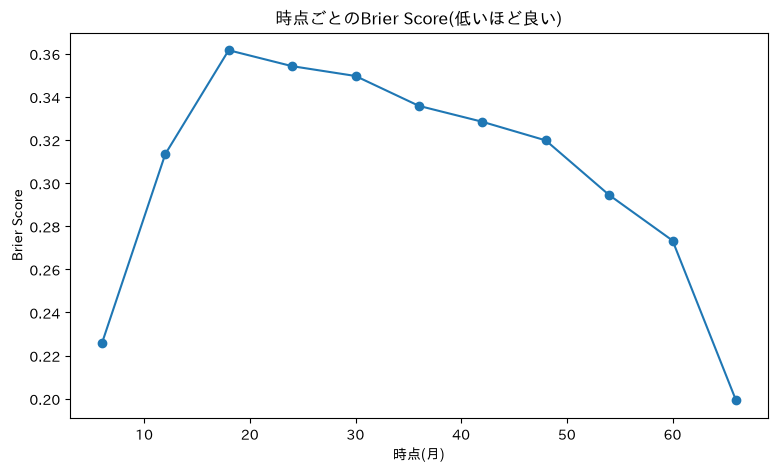

In [25]:
times, scores = brier_score(y_train, y_test, S_pred_matrix, time_points)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(times, scores, marker="o")
ax.set_xlabel("時点(月)")
ax.set_ylabel("Brier Score")
ax.set_title("時点ごとのBrier Score(低いほど良い)")
plt.savefig("../img/brier_score.png", dpi=100)

print("平均Brier Score:", scores.mean())

In [37]:
#frailty_modelで検証
df_train["PaymentMethod"] = df_full.set_index("CustomerID").loc[df_train["customerID"], "Payment Method"].values
df_test["PaymentMethod"] = df_full.set_index("CustomerID").loc[df_test["customerID"], "Payment Method"].values

payment_categories = df_full["Payment Method"].unique()
n_groups = len(payment_categories)

payment_idx_train = df_train["PaymentMethod"].astype(pd.CategoricalDtype(categories=payment_categories)).cat.codes.values
payment_idx_test = df_test["PaymentMethod"].astype(pd.CategoricalDtype(categories=payment_categories)).cat.codes.values

with pm.Model() as cox_frailty_train:
    h0 = pm.Gamma("h0", alpha=10, beta=10/0.055, shape=n_intervals)
    beta1 = pm.Normal("beta1", mu=0, sigma=1)
    beta2 = pm.Normal("beta2", mu=0, sigma=1)

    sigma_frailty = pm.Gamma("sigma_frailty", alpha=50, beta=50/1)
    log_z_raw = pm.Normal("log_z_raw", mu=0, sigma=sigma_frailty, shape=n_groups)
    z = pm.Deterministic("z", pt.exp(log_z_raw) / pt.mean(pt.exp(log_z_raw)))
    log_hazard_ratio = beta1*x1_train + beta2*x2_train
    h_i = h0[interval_idx_train] * pt.exp(log_hazard_ratio) * z[payment_idx_train]

    log_lik = event_train * pt.log(h_i) - h_i * exposure_train
    pm.Potential("loglike", pt.sum(log_lik))

    idata_frailty_train = pm.sample(draws=2000, tune=2000, chains=4, cores=4,
                                     target_accept=0.95, nuts_sampler="numpyro", random_seed=42)
    

NUTS[numpyro]: [h0, beta1, beta2, sigma_frailty, log_z_raw]
Compiling.. :   0%|       | 0/4000 [00:00<?, ?it/s]

  0%|                     | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|       | 0/4000 [00:00<?, ?it/s]


  0%|                     | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|    | 0/4000 [00:01<?, ?it/s]

Running chain 2:   0%|    | 0/4000 [00:01<?, ?it/s]


Running chain 3:   0%|    | 0/4000 [00:01<?, ?it/s]


Running chain 3:   5%| | 200/4000 [00:01<00:07, 497
Running chain 0:   5%| | 200/4000 [00:02<00:11, 337

Running chain 2:   5%| | 200/4000 [00:02<00:11, 326


Running chain 0:  10%| | 400/4000 [00:02<00:11, 304
Running chain 1:  10%| | 400/4000 [00:02<00:12, 294

Running chain 2:  10%| | 400/4000 [00:02<00:12, 297


Running chain 0:  15%|▏| 600/4000 [00:03<00:10, 323

Running chain 2:  15%|▏| 600/4000 [00:03<00:10, 310
Running chain 1:  15%|▏| 600/4000 [00:03<00:12, 276


Running chain 0:  20%|▏| 800/4000 [00:03<00:10, 318

Running chain 2:  20%|▏| 800/4000 [

In [40]:
beta1_m = idata_frailty_train.posterior["beta1"].values.mean()
beta2_m = idata_frailty_train.posterior["beta2"].values.mean()
z_m = idata_frailty_train.posterior["z"].values.reshape(-1, n_groups).mean(axis=0)

hazard_ratio_test_v2 = np.exp(beta1_m*x1_test + beta2_m*x2_test) * z_m[payment_idx_test]
c_index_v2 = concordance_index(t_test, -hazard_ratio_test_v2, event_test)
print("C-index (Contract + PaymentMethod):", c_index_v2)
print("C-index (Contractのみ、前回):", c_index)

h0_m_v2 = idata_frailty_train.posterior["h0"].values.reshape(-1, n_intervals).mean(axis=0)
S_pred_matrix_v2 = np.array([
    [piecewise_survival_test(t, h0_m_v2, breaks, hr) for t in time_points] for hr in hazard_ratio_test_v2])

times_v2, scores_v2 = brier_score(y_train, y_test, S_pred_matrix_v2, time_points)
print("平均Brier Score (Contract + PaymentMethod):", scores_v2.mean())
print("平均Brier Score (Contractのみ、前回):", 0.305)                                 

C-index (Contract + PaymentMethod): 0.78456793696204
C-index (Contractのみ、前回): 0.7673849113494235
平均Brier Score (Contract + PaymentMethod): 0.30315171206111496
平均Brier Score (Contractのみ、前回): 0.305


In [41]:
# 3ヶ月刻みに変更(24区間)
breaks_fine = np.arange(0, 75, 3)   
n_intervals_fine = len(breaks_fine) - 1

interval_idx_train_fine = np.clip(np.searchsorted(breaks_fine, t_train, side="right") - 1, 0, n_intervals_fine-1)
exposure_train_fine = t_train - breaks_fine[interval_idx_train_fine]

interval_idx_test_fine = np.clip(np.searchsorted(breaks_fine, t_test+0.5, side="right") - 1, 0, n_intervals_fine-1)

with pm.Model() as cox_frailty_train_fine:
    h0 = pm.Gamma("h0", alpha=10, beta=10/0.055, shape=n_intervals_fine)
    beta1 = pm.Normal("beta1", mu=0, sigma=1)
    beta2 = pm.Normal("beta2", mu=0, sigma=1)

    sigma_frailty = pm.Gamma("sigma_frailty", alpha=50, beta=50/1)
    log_z_raw = pm.Normal("log_z_raw", mu=0, sigma=sigma_frailty, shape=n_groups)
    z = pm.Deterministic("z", pt.exp(log_z_raw) / pt.mean(pt.exp(log_z_raw)))

    log_hazard_ratio = beta1*x1_train + beta2*x2_train
    h_i = h0[interval_idx_train_fine] * pt.exp(log_hazard_ratio) * z[payment_idx_train]

    log_lik = event_train * pt.log(h_i) - h_i * exposure_train_fine
    pm.Potential("loglike", pt.sum(log_lik))

    idata_fine = pm.sample(draws=2000, tune=2000, chains=4, cores=4,
                            target_accept=0.95, nuts_sampler="numpyro", random_seed=42)

NUTS[numpyro]: [h0, beta1, beta2, sigma_frailty, log_z_raw]
Compiling.. :   0%|       | 0/4000 [00:00<?, ?it/s]

  0%|                     | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|       | 0/4000 [00:00<?, ?it/s]


  0%|                     | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|    | 0/4000 [00:01<?, ?it/s]

Running chain 2:   0%|    | 0/4000 [00:01<?, ?it/s]


Running chain 3:   0%|    | 0/4000 [00:01<?, ?it/s]

Running chain 0:   5%| | 200/4000 [00:02<00:10, 359
Running chain 1:   5%| | 200/4000 [00:02<00:10, 357


Running chain 3:   5%| | 200/4000 [00:02<00:11, 336

Running chain 2:  10%| | 400/4000 [00:02<00:09, 396
Running chain 1:  10%| | 400/4000 [00:02<00:10, 337


Running chain 0:  10%| | 400/4000 [00:02<00:11, 304

Running chain 2:  15%|▏| 600/4000 [00:03<00:09, 340
Running chain 1:  15%|▏| 600/4000 [00:03<00:10, 310


Running chain 0:  15%|▏| 600/4000 [00:03<00:11, 288

Running chain 2:  20%|▏| 800/4000 [00:03<00:09, 320
Running chain 1:  20%|▏| 800/4000 [00

In [42]:
beta1_m_f = idata_fine.posterior["beta1"].values.mean()
beta2_m_f = idata_fine.posterior["beta2"].values.mean()
z_m_f = idata_fine.posterior["z"].values.reshape(-1, n_groups).mean(axis=0)

hazard_ratio_test_v3 = np.exp(beta1_m_f*x1_test + beta2_m_f*x2_test) * z_m_f[payment_idx_test]
c_index_v3 = concordance_index(t_test, -hazard_ratio_test_v3, event_test)
print("C-index (Contract + PaymentMethod +区間数2倍):", c_index_v3)
print("C-index (Contract + PaymentMethod):", c_index_v2)
print("C-index (Contractのみ、前回):", c_index)

h0_m_v3 = idata_fine.posterior["h0"].values.reshape(-1, n_intervals).mean(axis=0)
S_pred_matrix_v3 = np.array([
    [piecewise_survival_test(t, h0_m_v3, breaks, hr) for t in time_points] for hr in hazard_ratio_test_v3])

times_v3, scores_v3 = brier_score(y_train, y_test, S_pred_matrix_v3, time_points)

print("平均Brier Score (Contract + PaymentMethod + 区間数2倍):", scores_v3.mean())
print("平均Brier Score (Contract + PaymentMethod):", scores_v2.mean())
print("平均Brier Score (Contractのみ、前回):", 0.305)  

C-index (Contract + PaymentMethod +区間数2倍): 0.7636104060039303
C-index (Contract + PaymentMethod): 0.78456793696204
C-index (Contractのみ、前回): 0.7673849113494235
平均Brier Score (Contract + PaymentMethod + 区間数2倍): 0.4576740085017273
平均Brier Score (Contract + PaymentMethod): 0.30315171206111496
平均Brier Score (Contractのみ、前回): 0.305


# Telco Churn 生存時間分析 予測性能評価(C-index/Brier Score) セッションサマリー

## 目的

これまでの生存時間分析シリーズ(Exponential/Weibull/Cox/Frailty/Competing risks)が「推定・解釈」に焦点を当てていたのに対し、**「モデルが新しい顧客の解約リスクをどれだけ正確に予測できるか」という予測的妥当性**を評価する回。ユーザーの「事後分布の推定はやってきたが、それがビジネスにどうつながるか分かっていなかった」という問題意識が出発点。

## データ分割

`sklearn.train_test_split`で80/20に分割。**`event`列で層別化(`stratify`)**することで、訓練・テストの解約率をほぼ完全に一致させた(訓練26.54% vs テスト26.54%)。層別化の必要性は、「学習の歪み」(訓練データにイベントが偏ると学習自体が歪む)と「評価の歪み」(テストデータの偏りで評価数値自体が信頼できなくなる)の2つの側面から整理した。

## 評価指標の使い分け(このセッションの核心)

| 指標 | 何を測るか | ビジネス上の用途 |
|---|---|---|
| **C-index(Concordance Index)** | 「誰が誰より先に解約しそうか」という順位の正確さ | 解約リスク上位から優先的にアプローチする、リソース配分の意思決定 |
| **Brier Score** | 「解約する確率は具体的に何%か」という絶対値の正確さ(較正/キャリブレーション) | 解約確率に応じた金額換算、キャンペーンROI計算 |

「モデルの予測力」を単一の指標で語らず、**目的に応じて異なる指標を使い分ける**という視点が、統計的推定とビジネス活用を繋ぐ架け橋になることを実践的に確認した。

## 実装上の要点

- リスクスコアはexp(x^T beta)(ベースラインハザードh0(t)を除いた共変量部分)のみを使用。h0(t)は全顧客に共通してかかるため、比例ハザードの前提下では顧客間の順位に影響しないことを確認。
- C-indexは`lifelines.utils.concordance_index`を利用。符号の反転(`-risk_score`)が必要な理由(関数の定義が「大きいほど長生き」を期待するため)を確認。
- Brier scoreは`scikit-survival`の`brier_score`関数を利用。**IPCW(Inverse Probability of Censoring Weighting)**という、打ち切りを考慮した重み付けが必要であり、その打ち切り分布の推定に**訓練データ(y_train)を使う**理由(テストデータから推定するとdata leakageが起きるため)を整理した。

## 結果の推移

| モデル | C-index | Brier Score(平均) |
|---|---|---|
| ナイーブモデル(全員同一確率)の目安 | 0.5 | ≈0.197 |
| Contractのみ(Cox model) | 0.767 | 0.305 |
| Contract + PaymentMethod(Frailty model) | 0.785 | 0.303 |
| 上記 + 区間3ヶ月刻み(24区間) | 0.764 | 0.458 |

### 発見1: C-indexとBrier Scoreは独立して動く

PaymentMethod追加でC-indexは明確に改善(0.767→0.785)したが、Brier Scoreはほぼ変化なし(0.305→0.303)。**「順位付けの改善」と「確率の較正の改善」は別問題**であることを実データで確認した。frailty zが相対的な倍率としては機能しても、確率の絶対的なスケール感(h0)自体の較正には寄与しなかった可能性を考察。

### 発見2: 区間の細分化は、必ずしも性能向上につながらない(過学習の実例)

区間数を12→24に倍増させたところ、C-index・Brier Scoreとも明確に悪化(特にBrier Scoreは0.303→0.458と大幅悪化)。訓練データの解約者(約1,495人)を24区間×複数属性の組み合わせに分割すると、1セルあたりのサンプルサイズが極めて少なくなり、**訓練データのノイズを拾って汎化性能が落ちる、典型的な過学習**が発生したと解釈。「モデルの表現力を上げることが、常に予測性能の向上につながるわけではない」という、held-outデータでの評価があって初めて発見できる教訓。

### 全体を通じたBrier Scoreの構造的な弱さ

Brier Scoreは、いずれのモデルでもナイーブモデルの目安(0.197)を下回れず(=ナイーブモデルより悪い)、時点別に見ると18〜30ヶ月付近で特に悪化していた。これはPiecewise Exponentialの粗い時間区切りが、Weibullモデルで発見した「時間とともに減少するハザード」という構造を、より精密には捉えきれていない可能性を示唆しており、確率の較正という点では、シリーズ全体を通じて未解決の課題として残った。

---

## 主要な学び

1. **予測性能評価は、必ずheld-outデータで行う**: 訓練に使ったデータでモデルの当てはまりを見るだけでは、「モデルが訓練データを暗記しているだけ」なのか「本当に汎化する予測力があるか」を区別できない。層別化分割という一手間が、評価全体の信頼性を左右する。
2. **単一の指標で「良いモデル」と判断しない**: C-indexとBrier Scoreが異なる動きを見せたことは、「予測性能」が一枚岩の概念ではなく、目的(順位付けか、確率の絶対値か)に応じて評価軸を変える必要があることを具体的に示した。
3. **モデルの複雑化は、データ量とのバランスで判断する**: 区間の細分化という「モデルの柔軟性を上げる」操作が、実際にはtest setでの性能を悪化させた。これはMLB/サメで学んだ「グループごとのサンプルサイズ」への意識が、予測性能評価という新しい文脈でも同様に重要であることを裏付けた。
4. **データ漏洩(data leakage)への配慮は、評価パイプライン全体に及ぶ**: IPCWの打ち切り分布を訓練データから推定する、という一見些細な実装判断も、評価の妥当性を守るための重要な原則の一部である。

## 生存時間分析シリーズ全体の総括(最終回)

Exponential→Weibull→Cox→Frailty→Competing risks→予測性能評価という6段階を通じ、「モデルを構築し、事後分布を解釈する」段階から、「そのモデルが実務上どれだけ役立つかを定量的に評価する」段階まで、生存時間分析のワークフローを一通り経験した。特に本セッションは、これまでのセッションで培った推定・診断のスキルを、**ビジネス上の意思決定に接続する橋渡し**として機能し、「なぜこのモデリングをしているのか」という問いに、より具体的な答えを与える回となった。
